In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/messy_IMDB_dataset.csv', sep=';')

In [23]:
# Antal rader och kolumner
print('Shape:', df.shape)

Shape: (101, 12)


In [24]:
# Datatyper och icke-null-värden per kolumn
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IMBD title ID   100 non-null    str    
 1   Original titl�  100 non-null    str    
 2   Release year    100 non-null    str    
 3   Genr�           100 non-null    str    
 4   Duration        99 non-null     str    
 5   Country         100 non-null    str    
 6   Content Rating  77 non-null     str    
 7   Director        100 non-null    str    
 8   Unnamed: 8      0 non-null      float64
 9   Income          100 non-null    str    
 10   Votes          100 non-null    str    
 11  Score           100 non-null    str    
dtypes: float64(1), str(11)
memory usage: 9.6 KB


In [25]:
# Statistisk sammanfattning av numeriska kolumner
df.describe()

,Unnamed: 8
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [26]:
# De första 10 raderna
df.head(10)

,IMBD title ID,Original titl�,Release year,Genr�,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,NaN,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,NaN,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,NaN,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,NaN,$ 222831817,1.780.147,"8,9f"
5,tt0167260,The Lord of the Rings: The Return of the King,22 Feb 04,"Action, Adventure, Drama",201,New Zealand,PG-13,Peter Jackson,NaN,$ 1142271098,1.604.280,08.9
6,tt0108052,Schindler's List,1994-03-11,"Biography, Drama, History",Nan,USA,R,Steven Spielberg,NaN,$ 322287794,1.183.248,8.9
7,tt0050083,12 Angry Men,1957-09-04,"Crime, Drama",96,USA,Not Rated,Sidney Lumet,NaN,$ 576,668.473,8.9
8,tt1375666,Inception,2010-09-24,"Action, Adventure, Sci-Fi",148,USA,PG-13,Christopher Nolan,NaN,$ 869784991,2.002.816,8..8
9,tt0137523,Fight Club,10-29-99,Drama,Inf,UK,R,David Fincher,NaN,$ 101218804,1.807.440,8.8


In [27]:
# Antal saknade värden per kolumn
print(df.isnull().sum())

IMBD title ID       1
Original titl�      1
Release year        1
Genr�               1
Duration            2
Country             1
Content Rating     24
Director            1
Unnamed: 8        101
Income              1
 Votes              1
Score               1
dtype: int64


In [28]:
# Antal duplicerade rader
print('Dubbletter:', df.duplicated().sum())

Dubbletter: 0


## Steg 2 — Datarening (Data Cleaning)
### 2a. Saknade värden

In [29]:
# Identifiera vilka kolumner som har NaN
print(df.isnull().sum())

IMBD title ID       1
Original titl�      1
Release year        1
Genr�               1
Duration            2
Country             1
Content Rating     24
Director            1
Unnamed: 8        101
Income              1
 Votes              1
Score               1
dtype: int64


In [30]:
# Strategi: 
# - Unnamed: 8 (101 NaN) → ta bort kolumnen
# - Content Rating (24 NaN) → fyll med mode (vanligaste värdet)
# - Duration (2 NaN) → ta bort raderna

mode_val = df['Content Rating'].mode()[0]
df['Content Rating'] = df['Content Rating'].fillna(mode_val)
print(f'Content Rating fylld med mode: {mode_val}')

Content Rating fylld med mode: R


### 2b. Dubbletter

In [31]:
# Hitta dubbletter
print('Antal dubbletter:', df.duplicated().sum())

# Ta bort dubbletter
df = df.drop_duplicates()
print('Rader kvar:', len(df))

Antal dubbletter: 0
Rader kvar: 101


### 2c. Inkonsistenta format

In [32]:
# Inkonsistenta format
# Release year - Fixar blandade datumformat.
# Extrahera året med regex, leta efter 2 eller 4 siffriga år.
df['Release year'] = df['Release year'].str.extract(r'(\d{4}|\d{2})$|\b(\d{4})\b').bfill(axis=1).iloc[:, 0]
df['Release year'] = pd.to_numeric(df['Release year'], errors='coerce')

In [33]:
# Inkonsistenta format
# Income - Rensa valutatecken och konvertera till numeriskt.
# Ta bort $, mellanslag och kommatecken.
df['Income'] = df['Income'].str.replace(r'[$,\s]', '', regex=True)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

In [34]:
# [" Votes"] fungerade inte så var tvungen att kolla exakt vad den heter, 
# alltså med mellanslag både före och efter. Rensa mellanslag och konvertera till numeriskt.
print(df.columns.tolist())

['IMBD title ID', 'Original titl�', 'Release year', 'Genr�', 'Duration', 'Country', 'Content Rating', 'Director', 'Unnamed: 8', 'Income', ' Votes ', 'Score']


In [35]:
# Inkonsistenta format
# Votes - Rensa mellanslag och konvertera till numeriskt.
# Ta bort punkter (används som tusentalsavgränsare).
df[' Votes '] = df[' Votes '].str.replace('.', '', regex=False)
df[' Votes '] = pd.to_numeric(df[' Votes '], errors='coerce')

### 2d. Felaktiga värden

In [36]:
# Felaktiga värden.
# Steg 1: Kolla vilka rader som inte går att konvertera
mask = pd.to_numeric(df['Score'], errors='coerce').isna()
print(df.loc[mask, 'Score'])  # Visa de trasiga värdena

# Steg 2: Rensa — ta bort allt utom siffror och en punkt
df['Score'] = df['Score'].str.replace(r'[^0-9.]', '', regex=True)

# Steg 3: Hantera dubbla punkter som "8..8"
df['Score'] = df['Score'].str.replace(r'\.{2,}', '.', regex=True)

# Steg 4: Konvertera
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

3       9,.0
4       8,9f
8       8..8
10       8:8
13       NaN
14     ++8.7
15      8.7.
16    8,7e-0
21       8,6
Name: Score, dtype: str


### 2e. Onödiga kolumner

In [37]:
# Onödiga kolumner.
# Ta bort "Unnamed: 8" som var en tom kolumn.
df = df.drop(columns=['Unnamed: 8'])

# Verifiera
print(df.shape)  # Borde visa (101, 11)

(101, 11)


### 3. EDA-visualiseringar

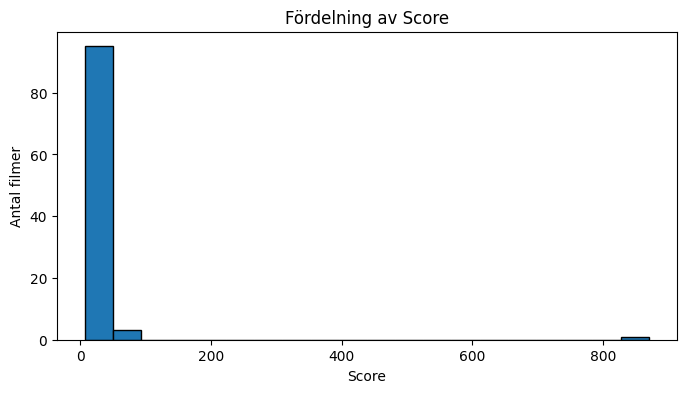

In [38]:
# Histogram över Score-fördelningen
# Skapa ett histogram för att se hur Score är fördelat efter rengöring.
plt.figure(figsize=(8, 4))
plt.hist(df['Score'].dropna(), bins=20, edgecolor='black')
plt.title('Fördelning av Score')
plt.xlabel('Score')
plt.ylabel('Antal filmer')
plt.show()

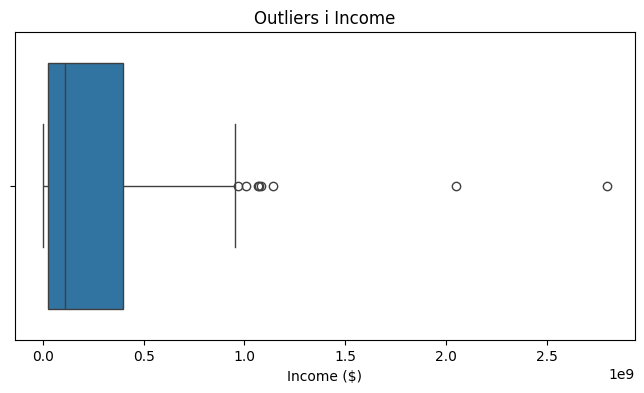

In [39]:
# Boxplot för att identifiera outliers i Income
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Income'])
plt.title('Outliers i Income')
plt.xlabel('Income ($)')
plt.show()

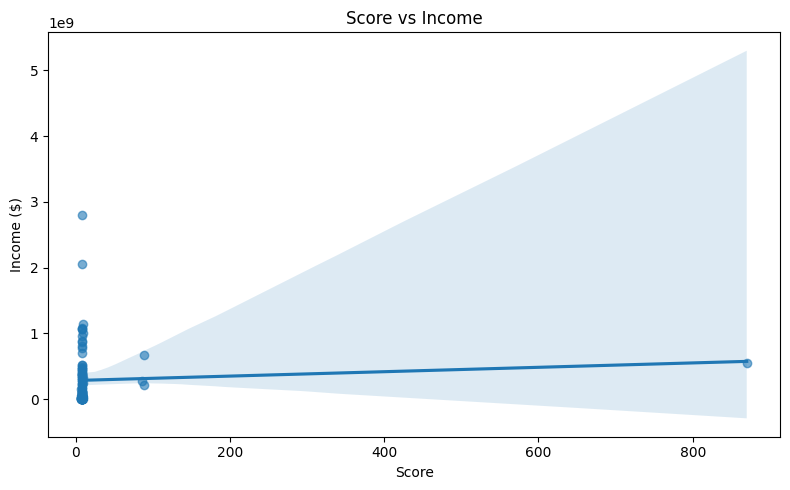

In [40]:
# Scatterplot för att se relationen mellan Score och Income
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Score', y='Income', scatter_kws={'alpha': 0.6})
plt.title('Score vs Income')
plt.xlabel('Score')
plt.ylabel('Income ($)')
plt.tight_layout()
plt.show()

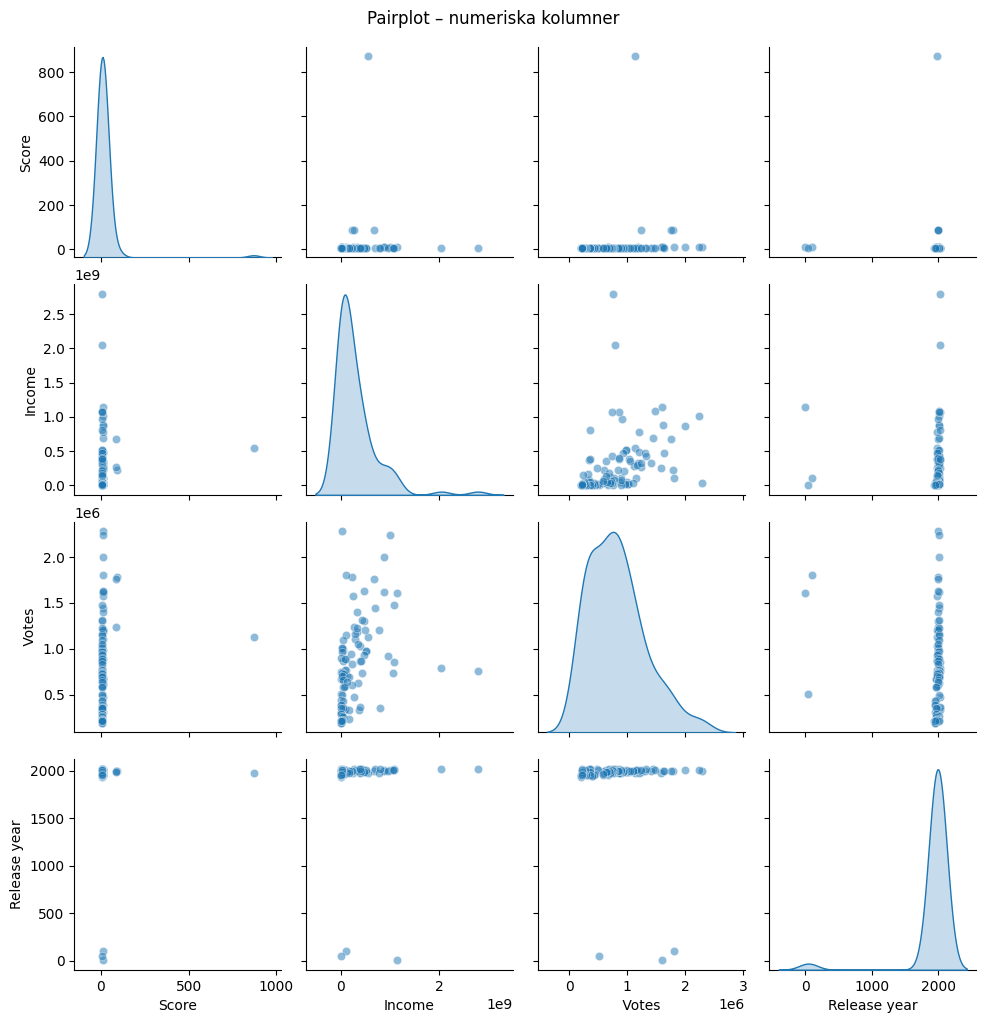

In [41]:
# Pairplot för att se relationer mellan flera numeriska variabler
# Väljer ut de numeriska kolumnerna vi vill jämföra
sns.pairplot(
    df[['Score', 'Income', ' Votes ', 'Release year']].dropna(),
    diag_kind='kde',      # valde att göra kurva istället för histogram på diagonalen
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot – numeriska kolumner', y=1.02)
plt.show()


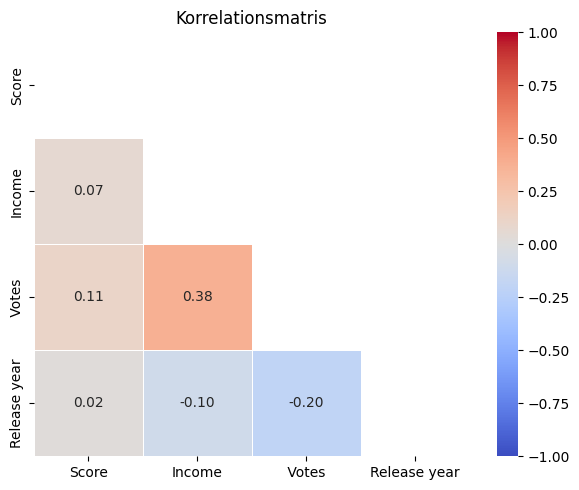

In [42]:
# Korrelationsmatris
# Beräkna korrelationen mellan de numeriska kolumnerna.
corr = df[['Score', 'Income', ' Votes ', 'Release year']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # döljer övre halvan

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Korrelationsmatris')
plt.tight_layout()
plt.show()
